# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
url='https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/hotels.csv'
df=pd.read_csv(url)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1.The key stakeholders are the hotel company's internal management, including operations managers, revenue/finance managers, marketing teams, and executives (CEO/CFO).

2.Revenue/finance managers want to identify which hotel or resort locations may need more funding at certain times of year, based on booking and performance trends. Operations managers want to understand reasons for cancellations so they can staff appropriately based on booking and cancellation frequency. Marketing teams want to identify which areas or channels to invest more in, based on booking popularity and frequency. Executives (CEO/CFO) want a clear picture of financial performance tied to this data, which can help make the case to stakeholders for further investment.

3.How can operations managers better anticipate staffing needs by analyzing cancellation rates and lead times across different booking periods?




## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [2]:
df.info()
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9404 entries, 0 to 9403
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           9404 non-null   object 
 1   is_canceled                     9404 non-null   int64  
 2   lead_time                       9404 non-null   int64  
 3   arrival_date_year               9404 non-null   int64  
 4   arrival_date_month              9404 non-null   object 
 5   arrival_date_week_number        9404 non-null   int64  
 6   arrival_date_day_of_month       9404 non-null   int64  
 7   stays_in_weekend_nights         9404 non-null   int64  
 8   stays_in_week_nights            9404 non-null   int64  
 9   adults                          9404 non-null   int64  
 10  children                        9404 non-null   int64  
 11  babies                          9404 non-null   int64  
 12  meal                            94

### Reflection:
1. Name at least one structure issue you’ve found (e.g., missing values, formatting problems).
2. How can you fix this structural issue?

### ✍️ Your Response: 🔧
1.Using df.duplicated().sum(), I found that the dataset contains 1,674 duplicate rows — meaning these rows appear more than once with identical values across all columns.

2.To fix this structural issue, I would use .drop_duplicates() to remove the repeated rows, which tidies up the data and prevents these duplicates from skewing any counts or averages in later analysis.



## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

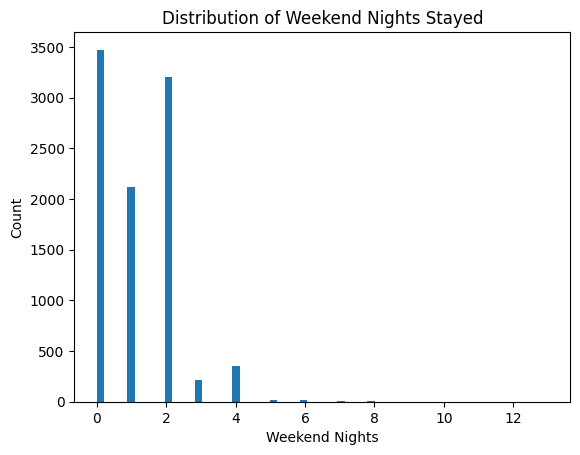

In [3]:
df['stays_in_weekend_nights'].describe()
plt.hist(df['stays_in_weekend_nights'], bins=60)
plt.title("Distribution of Weekend Nights Stayed")
plt.xlabel("Weekend Nights")
plt.ylabel("Count")
plt.show()


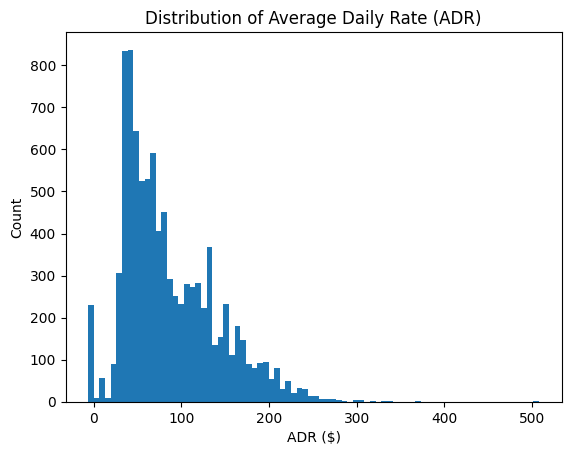

In [4]:
df['adr'].describe()
plt.hist(df['adr'], bins=80)
plt.title("Distribution of Average Daily Rate (ADR)")
plt.xlabel("ADR ($)")
plt.ylabel("Count")
plt.show()

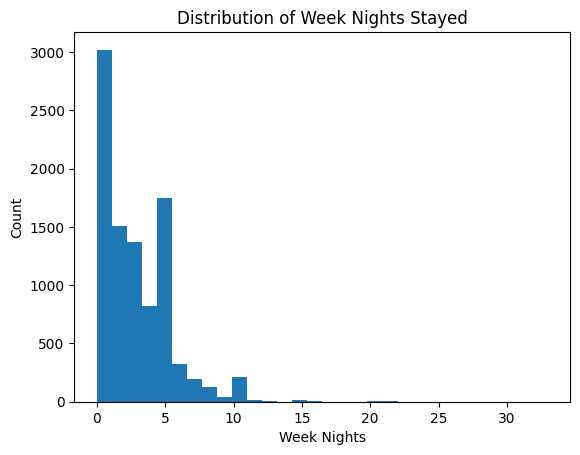

In [5]:
df['stays_in_week_nights'].describe()
plt.hist(df['stays_in_week_nights'], bins=30)
plt.title("Distribution of Week Nights Stayed")
plt.xlabel("Week Nights")
plt.ylabel("Count")
plt.show()

### Reflection:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Variable 1 – Summary and insights:** (stays_in_weekend_nights): I found that weekend night stays are mostly 0-2 nights, with a steep drop-off after that — a small number of outliers stretch out to 6-8 weekend nights, representing unusually long stay
- **Variable 2 – Summary and insights:** (adr): I found that the average daily rate is overwhelmingly under $100, with a long tail of higher-priced bookings stretching out toward $300-500.
- **Variable 3 – Summary and insights:** (stays_in_week_nights): I found that the distribution shows two spikes one around 0-2 nights, and a second, larger spike around 5 nights suggesting two common stay-length patterns among guests.


## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

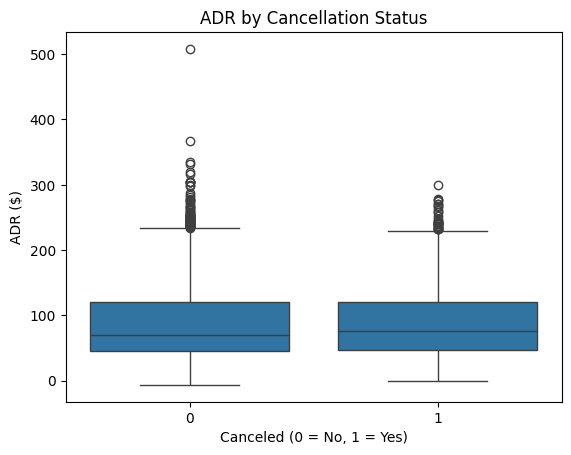

In [6]:
sns.boxplot(data=df, x='is_canceled', y='adr')
plt.title("ADR by Cancellation Status")
plt.xlabel("Canceled (0 = No, 1 = Yes)")
plt.ylabel("ADR ($)")
plt.show()

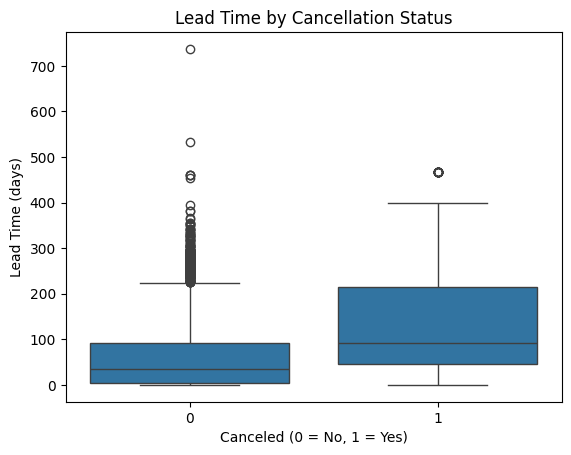

In [7]:
sns.boxplot(data=df, x='is_canceled', y='lead_time')
plt.title("Lead Time by Cancellation Status")
plt.xlabel("Canceled (0 = No, 1 = Yes)")
plt.ylabel("Lead Time (days)")
plt.show()

### Reflection:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧
- **Relationship 1:**  (ADR vs IS_canceled):I compared Average Daily Rate between canceled and non cancled bookings using a box plot. The two groups showed nearly idnetical distributions, similar medians of $70-75, and similar outliers this suggests that price alone doesn't have a strong relationship with whether booking gets canceled.
- **Relationship 2:** (lead_time vs Is_canceled) I compared lead time between canceld and on cacled booking using a box plot as well. I found that cancled bookings showed a noticely higher median lead time about 90 days compared to non canceled booking of about 35 days. This suggests that the longer in advance someone books, the more likely they are to eventually cancel this could be due to more time passing means more chances for plans to change.


## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection:
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧
1. Selected insight: Bookings with longer lead times show a noticeably higher likelihood of cancellation — the median lead time for canceled bookings about 90 days was more than double that of non-canceled bookings of about 35 days.
2. This is primarily a variability problem, the relationship isn't fixed or constant; cancellation likelihood shifts depending on how far in advance someone books, and that relationship could itself change over time (seasonally, by market segment, etc.). There's also an element of volume, since this pattern only becomes visible and reliable when looking across thousands of bookings rather than a handful.
3. This finding is "diagnostic" since it explains why cancellations happen (longer lead time correlates with higher risk), going a step beyond simply describing that cancellations occur. To act on it operationally (e.g., predicting which specific future bookings are likely to cancel), the hotel would eventually need predictive analytics, using lead time as one input among others.



## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### Reflection:
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. The clearest pattern was the relationship between lead time and cancellations. Bookings made far in advance were substantially more likely to be canceled than last-minute bookings. ADR, by contrast, showed almost no relationship with cancellation status.

2. This directly supports operations managers, who need to anticipate staffing needs. Bookings with long lead times represent higher cancellation risk, meaning they're less reliable for staffing projections than near-term bookings.

3. The hotel should treat high-lead-time bookings as lower-confidence when forecasting occupancy and staffing, and could consider incentives (like reduced cancellation flexibility or deposit requirements) for bookings made far in advance, to reduce revenue and scheduling uncertainty.

4. his assignment directly practices both of my personalized learning outcomes. Identifying that longer lead times correlate with higher cancellation rates required framing a clear, specific business problem moving from a vague question "what affects cancellations?" to a testable one tied to a single variable, the same skill I'm building toward writing clear problem statements for HR and legal settings. Building the boxplot and interpreting what it showed also practiced my second outcome: translating a visual pattern into a plain-language explanation a non-technical stakeholder (like an operations manager, or eventually a jury) could act on without needing to read the underlying statistics themselves.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [8]:
!jupyter nbconvert --to html "assignment_05_eda.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_05_eda.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execu